# DAG – Honda RA621H Assembly
**Struktur Data dan Algoritma | Proyek 2025**

Notebook ini membangun salah satu dari alat yang kita butuhkan untuk membuat proyeknnya yaitu Directed Acyclic Graph (DAG) dari dataset perakitan Honda RA621H.
- 103 nodes (komponen)
- 216 directed edges (dependency)
- 16 root nodes (tidak punya predecessor)

**DAG (Directed Acyclic Graph)**
adalah cara kita menggambarkan dependency itu sebagai sebuah graph (jaringan).

- Setiap komponen = 1 node (titik)
- Setiap dependency = 1 directed edge (panah searah)
- Panah berarti "harus selesai dulu"

contoh visualnya 

<p style="font-size:12px;">
C001 (Cylinder Block) → C002 (Crankshaft) → C003 (Connecting Rods) → C004 (Pistons)
</p>

**Acyclic** artinya tidak ada loop/siklus — tidak mungkin A butuh B, dan B butuh A. Kalau ada loop, pekerjaan tidak bisa dimulai sama sekali. DAG kamu valid, tidak ada cycle.

Root nodes adalah komponen yang tidak punya dependency apapun — bisa langsung dikerjakan dari hari pertama. Di dataset kamu ada 10 root nodes:


In [11]:
# Cell 0 – Import library
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, deque

print('Library siap.')

Library siap.


## Cell 0 — Import Library

Empat library yang digunakan di notebook ini:

| Library | Fungsi |
|---------|--------|
| `pandas` | Membaca file Excel dan memanipulasi data tabular |
| `networkx` | Membangun dan menganalisis struktur DAG (`DiGraph`) |
| `matplotlib` | Membuat visualisasi: graph, histogram distribusi degree |
| `collections.defaultdict` | Agregasi data per subsystem secara efisien |

<p style="font-size:12px;">
C001 (V6 Cylinder Block)   ← root, tidak ada prasyarat

↓
<p style="font-size:12px;">
C002 (Crankshaft)          ← butuh C001 selesai dulu

↓
<p style="font-size:12px;">
C003 (Connecting Rods)     ← butuh C001 dan C002

↓
<p style="font-size:12px;">
C004 (Pistons)             ← butuh C001 dan C003
</p>

## Statistik Dataset

| Metrik | Nilai |
|--------|-------|
| Total komponen (nodes) | **103** |
| Total dependency (edges) | **216** |
| Root nodes (tanpa prasyarat) | **10** |
| Leaf nodes (tidak jadi prasyarat lain) | **8** |
| Subsystem | **19** |

In [12]:
# Cell 1 – Load dataset dari CSV
df_comp    = pd.read_csv('output_csv/components.csv')
df_edge    = pd.read_csv('output_csv/dependency_edges.csv')
df_summary = pd.read_csv('output_csv/summary_stats.csv')

# Bersihkan & rename kolom komponen
df_comp = df_comp[['Component ID', 'Component Name', 'Subsystem',
                    'Depends On (IDs)', 'Duration (hrs)', 'Is Critical Path']].copy()
df_comp['is_critical'] = df_comp['Is Critical Path'].str.contains('CRITICAL', na=False)

# Bersihkan kolom edges
df_edge = df_edge[['FROM (Prerequisite ID)', 'FROM Name',
                    'TO (Dependent ID)', 'TO Name', 'Edge Weight (hrs)']].copy()

print(f'Komponen (nodes) : {len(df_comp)}')
print(f'Edges            : {len(df_edge)}')
df_comp.head()

Komponen (nodes) : 103
Edges            : 216


,Component ID,Component Name,Subsystem,Depends On (IDs),Duration (hrs),Is Critical Path,is_critical
0,C001,V6 Cylinder Block (1.6L 90° Bank),ICE – Internal Combustion Engine,NaN,48,✓ CRITICAL,True
1,C002,Crankshaft,ICE – Internal Combustion Engine,C001,24,✓ CRITICAL,True
2,C003,Connecting Rods (x6),ICE – Internal Combustion Engine,"C001,C002",12,✓ CRITICAL,True
3,C004,Pistons (x6),ICE – Internal Combustion Engine,"C001,C003",16,✓ CRITICAL,True
4,C005,Piston Rings (x18),ICE – Internal Combustion Engine,C004,4,—,False


## Cell 1 — Load Dataset

Dataset dibaca dari file **`Honda_RA621H_Assembly_Dataset.xlsx`** dengan dua sheet utama:

- **`Components`** — 103 baris, satu baris per komponen. Kolom penting: `Component ID`, `Component Name`, `Subsystem`, `Depends On (IDs)`, `Duration (hrs)`, `Is Critical Path`
- **`Dependency_Edges`** — 216 baris, satu baris per dependency edge. Kolom: `FROM`, `TO`, `Edge Weight (hrs)`

### Output yang dihasilkan

- Komponen (nodes) : 103
- Edges            : 216

Tabel preview menunjukkan 5 komponen pertama dari subsystem **ICE (Internal Combustion Engine)**:

| ID | Komponen | Depends On | Duration |
|----|----------|------------|----------|
| C001 | V6 Cylinder Block | — (root) | 48 jam |
| C002 | Crankshaft | C001 | 24 jam |
| C003 | Connecting Rods | C001, C002 | 12 jam |
| C004 | Pistons | C001, C003 | 16 jam |
| C005 | Piston Rings | C004 | 4 jam |

Kolom `is_critical` (boolean) ditambahkan dari kolom `Is Critical Path` untuk memudahkan filtering di cell berikutnya.

In [13]:
# Cell 2 – Bangun DAG dengan NetworkX
G = nx.DiGraph()

# Tambah nodes beserta atributnya
for _, row in df_comp.iterrows():
    G.add_node(
        row['Component ID'],
        label=row['Component Name'],
        subsystem=row['Subsystem'],
        duration=row['Duration (hrs)'],
        is_critical=row['is_critical']
    )

# Tambah directed edges dari dependency_edges.csv
for _, row in df_edge.iterrows():
    src    = row['FROM (Prerequisite ID)']
    dst    = row['TO (Dependent ID)']
    weight = row['Edge Weight (hrs)']
    G.add_edge(src, dst, weight=weight)

print(f'Nodes            : {G.number_of_nodes()}')
print(f'Edges            : {G.number_of_edges()}')
print(f'Is DAG (acyclic) : {nx.is_directed_acyclic_graph(G)}')

Nodes            : 103
Edges            : 216
Is DAG (acyclic) : True


## Cell 2 — Bangun DAG dengan NetworkX

Di cell ini, seluruh data dari DataFrame dikonversi menjadi struktur **`nx.DiGraph`** (Directed Graph dari library NetworkX).

### Cara kerjanya

**Step 1 — Tambah nodes:**
Setiap baris di `df_comp` menjadi satu node di graph, dengan atribut yang ikut tersimpan di dalamnya:

```python
G.add_node(
    row['Component ID'],   # key node, contoh: 'C001'
    label       = ...,     # nama lengkap komponen
    subsystem   = ...,     # subsystem (ICE, Turbo, dll.)
    duration    = ...,     # durasi pengerjaan dalam jam
    is_critical = ...      # True jika ada di critical path
)
```

**Step 2 — Tambah directed edges:**
Setiap baris di `df_edge` menjadi satu panah dari `FROM` ke `TO`, artinya *"FROM harus selesai sebelum TO bisa dimulai"*:

```python
G.add_edge(src, dst, weight=weight)
# contoh: G.add_edge('C001', 'C002', weight=48)
# → C001 harus selesai (48 jam) sebelum C002 bisa dimulai
```

### Output yang dihasilkan
- Nodes           : 103
- Edges           : 216
- Is DAG (acyclic): True

**`Is DAG (acyclic): True`** adalah konfirmasi paling penting di seluruh notebook ini. Artinya tidak ada siklus dalam dataset — urutan assembly yang valid *pasti ada* dan bisa ditemukan dengan Topological Sort.

Kalau nilainya `False`, berarti ada komponen yang saling menunggu satu sama lain (A butuh B, B butuh A), dan assembly tidak bisa dimulai dari mana pun — kondisi **deadlock**.

In [14]:
# Cell 3 – Identifikasi root nodes & leaf nodes
root_nodes = [n for n, d in G.in_degree()  if d == 0]
leaf_nodes  = [n for n, d in G.out_degree() if d == 0]

print(f'Root nodes ({len(root_nodes)}):')
for n in root_nodes:
    print(f'  {n} – {G.nodes[n]["label"]}')

print(f'\nLeaf nodes ({len(leaf_nodes)}):')
for n in leaf_nodes:
    print(f'  {n} – {G.nodes[n]["label"]}')

Root nodes (10):
  C001 – V6 Cylinder Block (1.6L 90° Bank)
  C018 – Compressor Housing
  C025 – MGU-H Rotor & Magnet Assembly
  C030 – MGU-K Rotor & Magnet Assembly
  C035 – Li-Ion Battery Cells (ES)
  C039 – Dry-Sump Oil Tank
  C043 – Water Pump (Electric)
  C046 – Fuel Tank (FIA Bladder, ~100kg capacity)
  C049 – Engine Control Unit (ECU) – FIA Standard
  C052 – Carbon Fibre Monocoque (Survival Cell)

Leaf nodes (8):
  C041 – Oil Cooler
  C042 – Oil Filter & Pressure Regulators
  C045 – Coolant Hoses & Distribution Lines
  C048 – Fuel Filter & Lines
  C053 – Roll Hoop (Halo + Main)
  C054 – Ballast Weights
  C080 – Driveshafts (x2)
  C103 – Full Car Systems Check & Sign-Off


## Cell 3 — Root Nodes & Leaf Nodes

### Root Nodes — 10 komponen tanpa prasyarat

Root nodes adalah komponen dengan **in-degree = 0** — tidak ada node lain yang harus selesai sebelum mereka bisa dikerjakan. Ini adalah **titik-titik start** dari seluruh proses assembly.

- C001 – V6 Cylinder Block        → fondasi ICE, paling pertama dikerjakan
- C018 – Compressor Housing        → titik awal subsystem Turbocharger
- C025 – MGU-H Rotor & Magnet     → titik awal subsystem MGU-H
- C030 – MGU-K Rotor & Magnet     → titik awal subsystem MGU-K
- C035 – Li-Ion Battery Cells      → titik awal Energy Store
- C039 – Dry-Sump Oil Tank         → titik awal Lubrication System
- C043 – Water Pump (Electric)     → titik awal Cooling System
- C046 – Fuel Tank                 → titik awal Fuel System
- C049 – ECU (FIA Standard)        → titik awal Electronics & Control
- C052 – Carbon Fibre Monocoque   → titik awal Chassis

Seluruh 10 root nodes ini bisa dikerjakan **secara paralel** di hari pertama assembly — masing-masing dimulai oleh tim yang berbeda secara bersamaan.

### Leaf Nodes — 8 komponen paling akhir

Leaf nodes adalah komponen dengan **out-degree = 0** — tidak ada komponen lain yang menunggunya. Ini adalah **titik-titik akhir** dari DAG.

- C041 – Oil Cooler                → akhir dari chain Lubrication
- C042 – Oil Filter & Regulators  → akhir dari chain Lubrication
- C045 – Coolant Hoses             → akhir dari chain Cooling
- C048 – Fuel Filter & Lines       → akhir dari chain Fuel
- C053 – Roll Hoop                 → akhir dari chain Chassis
- C054 – Ballast Weights           → akhir dari chain Chassis
- C080 – Driveshafts               → akhir dari chain Drivetrain
- C103 – Full Car Sign-Off         → node terakhir seluruh DAG

`C103 – Full Car Systems Check & Sign-Off` adalah satu-satunya **final node** yang mengakhiri seluruh proses — tidak ada komponen apapun yang dikerjakan setelah ini.

In [15]:
# Cell 4 – Statistik DAG per subsystem + summary stats
subsystem_counts = df_comp.groupby('Subsystem').agg(
    jumlah_komponen=('Component ID', 'count'),
    total_durasi=('Duration (hrs)', 'sum'),
    komponen_kritis=('is_critical', 'sum')
).sort_values('total_durasi', ascending=False)

print('Statistik per Subsystem:')
print(subsystem_counts.to_string())

# ── Summary Stats dari CSV ───────────────────────────────────────────
# Format: 2 pasang kolom (metric|value) side by side, baris 0 = header duplikat
raw = df_summary.copy()
raw.columns = ['metric_1', 'value_1', 'metric_2', 'value_2']

# Ambil pasangan kiri & kanan, drop baris kosong / header
left  = raw[['metric_1', 'value_1']].rename(columns={'metric_1': 'metric', 'value_1': 'value'})
right = raw[['metric_2', 'value_2']].rename(columns={'metric_2': 'metric', 'value_2': 'value'})
stats = pd.concat([left, right]).dropna(subset=['metric'])
stats = stats[~stats['metric'].isin(['Metric', 'Subsystem', 'Dataset Summary – Honda RA621H F1 Assembly',
                                      'Subsystem Breakdown', 'NaN'])]
stats = stats[~stats['value'].isin(['Value', 'Color Code', float('nan')])].reset_index(drop=True)

print('\nDataset Summary – Honda RA621H:')
print(f'{"Metric":<40} {"Value":>10}')
print('-' * 52)
for _, row in stats.iterrows():
    if str(row['metric']) not in ['nan', 'Total Duration (hrs)']:
        print(f'{str(row["metric"]):<40} {str(row["value"]):>10}')

Statistik per Subsystem:
                                  jumlah_komponen  total_durasi  komponen_kritis
Subsystem                                                                       
ICE – Internal Combustion Engine               15           254                9
Aerodynamics – Front                            5           148                3
Chassis & Monocoque                             4           132                3
Turbocharger System                             9           114                6
Gearbox & Drivetrain                            5           112                4
Final Assembly                                  7            98                7
Aerodynamics – Rear                             4            84                2
Braking System                                  6            68                2
Hybrid – MGU-H                                  5            68                4
Hybrid – MGU-K                                  5            58                4
Ene

## Cell 4 — Statistik DAG per Subsystem

Tabel ini merangkum **19 subsystem** berdasarkan total durasi, jumlah komponen, dan berapa yang masuk critical path — diurutkan dari subsystem paling berat (total jam) ke paling ringan.

### Insight dari output

**ICE (Internal Combustion Engine)** — subsystem terberat dengan 254 jam total, 15 komponen, 9 di antaranya critical. ICE adalah tulang punggung perakitan: hampir semua subsystem lain (Turbo, MGU-H, MGU-K, Gearbox) bergantung padanya secara langsung atau tidak langsung.

**Aerodynamics Front (148 jam)** — mengejutkan berada di posisi 2. Front wing adalah komponen paling kompleks secara aerodinamika, butuh 4–6 minggu desain dan pengujian sebelum perakitan fisik.

**Final Assembly (7 komponen, semua critical)** — seluruh 7 komponen di subsystem ini masuk critical path karena ini adalah tahap integrasi: setiap langkah integrasi harus terjadi secara berurutan tanpa bisa diparalelkan.

**Wheels & Tyres, Cooling System, Fuel System** — total durasi paling rendah dan tidak ada komponen critical. Subsystem ini bisa dikerjakan sangat fleksibel sambil menunggu subsystem utama selesai.

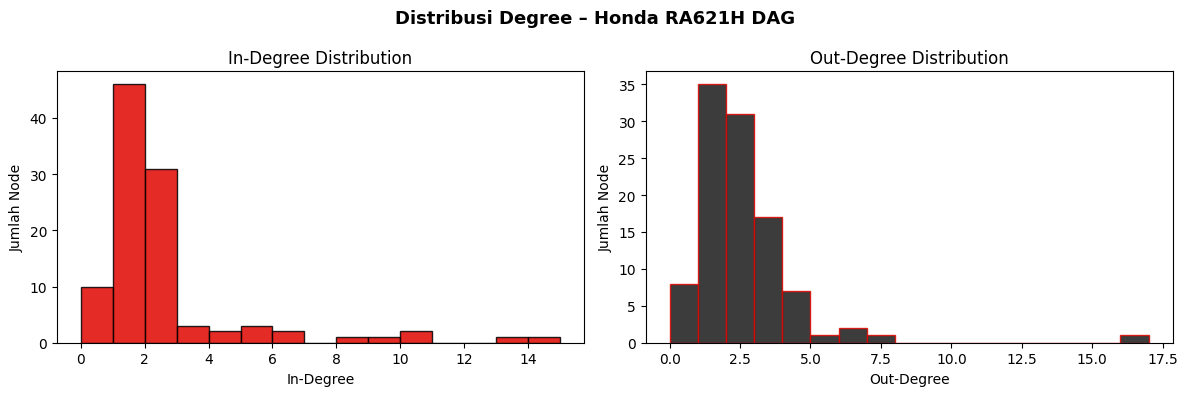

Plot tersimpan: dag_degree_distribution.png


In [16]:
# Cell 5 – In-degree & out-degree distribution
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Degree – Honda RA621H DAG', fontsize=13, fontweight='bold')

axes[0].hist(list(in_deg.values()), bins=range(0, max(in_deg.values())+2),
             color='#E10600', edgecolor='black', alpha=0.85)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Jumlah Node')

axes[1].hist(list(out_deg.values()), bins=range(0, max(out_deg.values())+2),
             color='#1a1a1a', edgecolor='#E10600', alpha=0.85)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Jumlah Node')

plt.tight_layout()
plt.savefig('dag_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: dag_degree_distribution.png')

## Cell 5 — In-Degree & Out-Degree Distribution

Dua histogram ini menggambarkan **distribusi konektivitas** setiap node dalam DAG.

### In-Degree Distribution (histogram kiri)

**In-degree** = jumlah prasyarat yang dimiliki sebuah komponen — berapa banyak komponen lain yang harus selesai sebelum dia bisa dimulai.

- **In-degree 0** → root nodes (10 komponen), bisa langsung dikerjakan
- **In-degree tinggi** → komponen yang sangat bergantung pada banyak hal, seperti `C015 – Engine Assembly` yang menunggu 14 komponen ICE selesai semua

### Out-Degree Distribution (histogram kanan)

**Out-degree** = berapa banyak komponen lain yang menunggu node ini selesai.

- **Out-degree 0** → leaf nodes (8 komponen), tidak ada yang menunggu
- **Out-degree tinggi** → node **bottleneck** — kalau komponen ini terlambat 1 jam, efeknya bisa melambatkan 5–6 komponen downstream sekaligus

Distribusi keduanya condong ke kiri (kebanyakan node punya degree rendah), menunjukkan DAG ini punya beberapa **hub nodes** yang sangat terhubung di tengah-tengah, dan banyak node "pinggiran" dengan koneksi sedikit.

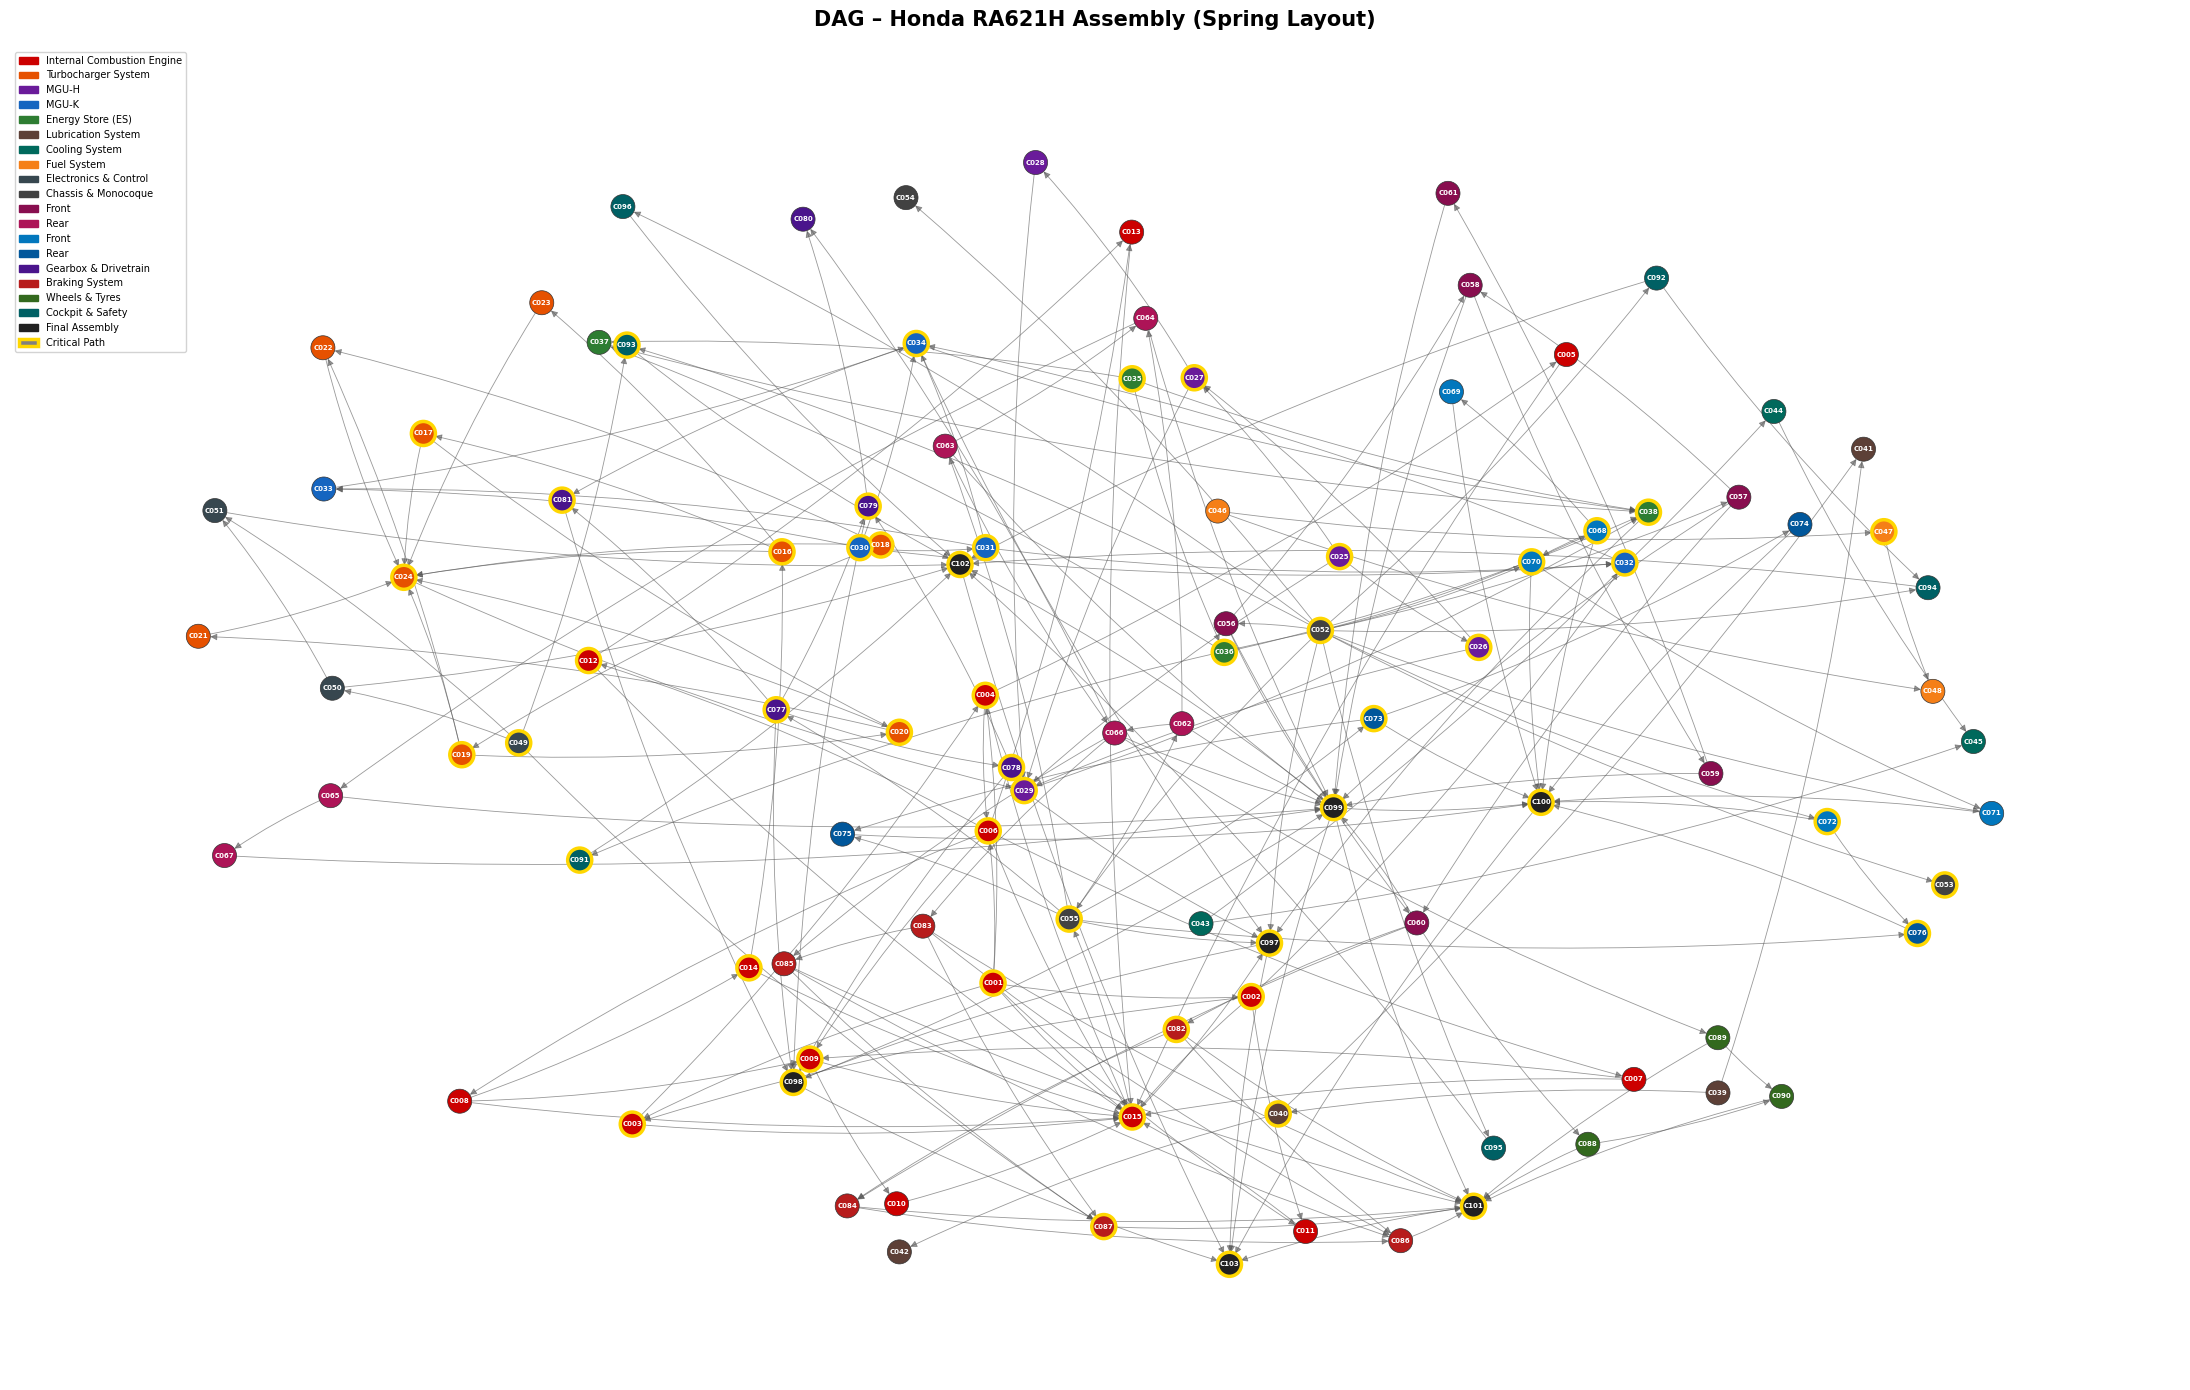

In [17]:
# Cell 6 – Visualisasi DAG (subsystem view, spring layout)

# Ambil color code per subsystem dari summary_stats jika tersedia
raw2 = df_summary.copy()
raw2.columns = ['metric_1', 'value_1', 'metric_2', 'value_2']
subsys_block = raw2[raw2['metric_1'] == 'Subsystem'].index
if len(subsys_block) > 0:
    idx_start = subsys_block[0] + 1
    df_colors = raw2.iloc[idx_start:].dropna(subset=['metric_1', 'value_2'])
    df_colors = df_colors[df_colors['value_2'].str.startswith('#', na=False)]
    color_map_csv = dict(zip(df_colors['metric_1'], df_colors['value_2']))
else:
    color_map_csv = {}

# Fallback palette kalau color tidak ada di CSV
fallback_palette = [
    '#E10600', '#FF6B35', '#FFB347', '#4CAF50',
    '#2196F3', '#9C27B0', '#00BCD4', '#795548', '#607D8B'
]
subsystems = df_comp['Subsystem'].unique()
subsystem_color = {}
for i, s in enumerate(subsystems):
    subsystem_color[s] = color_map_csv.get(s, fallback_palette[i % len(fallback_palette)])

node_colors      = [subsystem_color.get(G.nodes[n].get('subsystem', ''), '#999999') for n in G.nodes()]
node_edge_colors = ['#FFD700' if G.nodes[n]['is_critical'] else '#333333' for n in G.nodes()]
node_linewidths  = [2.5      if G.nodes[n]['is_critical'] else 0.5        for n in G.nodes()]

plt.figure(figsize=(22, 14))
plt.title('DAG – Honda RA621H Assembly (Spring Layout)', fontsize=15, fontweight='bold', pad=15)

pos = nx.spring_layout(G, seed=42, k=1.5)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300,
                       edgecolors=node_edge_colors, linewidths=node_linewidths)
nx.draw_networkx_edges(G, pos, edge_color='#555555', arrows=True,
                       arrowsize=10, width=0.6, alpha=0.6,
                       connectionstyle='arc3,rad=0.05')
nx.draw_networkx_labels(G, pos, labels={n: n for n in G.nodes()},
                        font_size=5, font_color='white', font_weight='bold')

patches = [mpatches.Patch(color=subsystem_color[s], label=s.split('–')[-1].strip())
           for s in subsystems]
patches.append(mpatches.Patch(facecolor='gray', edgecolor='#FFD700',
                               linewidth=2.5, label='Critical Path'))
plt.legend(handles=patches, loc='upper left', fontsize=7, framealpha=0.85)

plt.axis('off')
plt.tight_layout()
plt.show()


## Cell 6 — Visualisasi DAG (Spring Layout)

Plot ini menampilkan **seluruh 103 node dan 216 edge** dalam satu pandang menggunakan **spring layout** dari NetworkX.

### Cara membaca visualisasi ini

- **Warna node** → subsystem masing-masing komponen (lihat legend di pojok kiri atas)
- **Border emas 🟡** → node ada di critical path (52 komponen dari dataset awal)
- **Arah panah** → dari prasyarat menuju komponen yang bergantung padanya
- **Posisi node** → ditentukan algoritma force-directed (spring) — node yang saling terhubung lebih banyak akan berkelompok berdekatan

### Kenapa spring layout?

Spring layout menggunakan analogi **pegas** — node saling tarik-menarik berdasarkan koneksinya. Hasilnya, komponen dalam subsystem yang sama cenderung **mengelompok alami** karena mereka berbagi banyak koneksi internal. Kluster yang terlihat di tengah biasanya adalah subsystem dengan konektivitas tinggi ke bagian lain (ICE, Final Assembly).

### Yang bisa diobservasi

- Ada **kluster besar di tengah** → itu adalah node-node ICE dan Final Assembly yang menjadi penghubung mayoritas subsystem
- **Node-node di pinggir** → subsystem yang lebih independen seperti Wheels & Tyres, Cockpit
- Komponen dengan border emas (critical path) cenderung berada di jalur "tengah" graph, bukan di pinggir

In [18]:
# Cell 7 – Kahn's Algorithm (Topological Sort berbasis BFS)
# Implementasi manual, tidak pakai nx.topological_sort()

def kahns_topological_sort(graph):
    """
    Kahn's Algorithm – BFS-based topological sort.
    Returns:
        topo_order : list node dalam urutan assembly yang valid
        in_degree  : dict in-degree akhir (semua 0 jika DAG valid)
    """
    in_degree = defaultdict(int)

    # Hitung in-degree tiap node
    for node in graph.nodes():
        if node not in in_degree:
            in_degree[node] = 0
        for _ in graph.predecessors(node):
            in_degree[node] += 1

    # Queue: semua node dengan in-degree 0 (root nodes)
    queue      = deque(sorted([n for n, d in in_degree.items() if d == 0]))
    topo_order = []

    while queue:
        node = queue.popleft()
        topo_order.append(node)

        # Kurangi in-degree semua successor
        for successor in sorted(graph.successors(node)):
            in_degree[successor] -= 1
            if in_degree[successor] == 0:
                queue.append(successor)

    return topo_order, in_degree


topo_order, final_in_degree = kahns_topological_sort(G)

# Validasi: kalau semua node terproses → tidak ada cycle
is_valid = len(topo_order) == G.number_of_nodes()
print(f'Topological sort valid (no cycle) : {is_valid}')
print(f'Total node diproses               : {len(topo_order)} / {G.number_of_nodes()}')

Topological sort valid (no cycle) : True
Total node diproses               : 103 / 103


In [19]:
# Cell 8 – Tampilkan urutan assembly hasil Kahn's
print(f'{"No.":<5} {"ID":<6} {"Nama Komponen":<45} {"Subsystem":<35} {"Durasi":>8}  Kritis?')
print('-' * 115)

for i, node_id in enumerate(topo_order, start=1):
    attr = G.nodes[node_id]
    flag = '★ CRITICAL' if attr['is_critical'] else ''
    print(f'{i:<5} {node_id:<6} {attr["label"][:44]:<45} {attr["subsystem"][:34]:<35} {attr["duration"]:>6} hrs  {flag}')

No.   ID     Nama Komponen                                 Subsystem                             Durasi  Kritis?
-------------------------------------------------------------------------------------------------------------------
1     C001   V6 Cylinder Block (1.6L 90° Bank)             ICE – Internal Combustion Engine        48 hrs  ★ CRITICAL
2     C018   Compressor Housing                            Turbocharger System                     18 hrs  ★ CRITICAL
3     C025   MGU-H Rotor & Magnet Assembly                 Hybrid – MGU-H                          20 hrs  ★ CRITICAL
4     C030   MGU-K Rotor & Magnet Assembly                 Hybrid – MGU-K                          18 hrs  ★ CRITICAL
5     C035   Li-Ion Battery Cells (ES)                     Energy Store (ES)                       20 hrs  ★ CRITICAL
6     C039   Dry-Sump Oil Tank                             Lubrication System                       6 hrs  
7     C043   Water Pump (Electric)                         Cooling System

In [20]:
# Cell 9 – Ringkasan akhir DAG + Kahn's
critical_nodes = [n for n in G.nodes() if G.nodes[n]['is_critical']]
avg_in  = sum(dict(G.in_degree()).values())  / G.number_of_nodes()
avg_out = sum(dict(G.out_degree()).values()) / G.number_of_nodes()

# Cross-check dengan summary_stats.csv
assert G.number_of_nodes() == 103, f'Node count mismatch: {G.number_of_nodes()}'
assert G.number_of_edges() == 216, f'Edge count mismatch: {G.number_of_edges()}'
assert len(root_nodes)     == 10,  f'Root node mismatch: {len(root_nodes)}'
print('Assertions passed: node/edge/root count sesuai summary_stats.csv ✓')

print("\nRINGKASAN – Honda RA621H DAG + Kahn's Topological Sort")
print(f'  Total nodes              : {G.number_of_nodes()}')
print(f'  Total edges              : {G.number_of_edges()}')
print(f'  Is acyclic (valid DAG)   : {nx.is_directed_acyclic_graph(G)}')
print(f'  Root nodes               : {len(root_nodes)}')
print(f'  Leaf nodes               : {len(leaf_nodes)}')
print(f'  Critical path nodes      : {len(critical_nodes)}')
print(f'  Avg in-degree            : {avg_in:.2f}')
print(f'  Avg out-degree           : {avg_out:.2f}')
print(f"  Kahn's sort valid        : {len(topo_order) == G.number_of_nodes()}")
print(f'  Urutan pertama assembly  : {topo_order[0]} – {G.nodes[topo_order[0]]["label"]}')
print(f'  Urutan terakhir assembly : {topo_order[-1]} – {G.nodes[topo_order[-1]]["label"]}')
print('\nDAG + Topological Sort selesai. Lanjut ke CPM.')

Assertions passed: node/edge/root count sesuai summary_stats.csv ✓

RINGKASAN – Honda RA621H DAG + Kahn's Topological Sort
  Total nodes              : 103
  Total edges              : 216
  Is acyclic (valid DAG)   : True
  Root nodes               : 10
  Leaf nodes               : 8
  Critical path nodes      : 52
  Avg in-degree            : 2.10
  Avg out-degree           : 2.10
  Kahn's sort valid        : True
  Urutan pertama assembly  : C001 – V6 Cylinder Block (1.6L 90° Bank)
  Urutan terakhir assembly : C103 – Full Car Systems Check & Sign-Off

DAG + Topological Sort selesai. Lanjut ke CPM.


In [ ]:
def cpm_forward_pass(graph, topo_order):
    """
    Forward pass CPM – hitung ES dan EF tiap node.
    ES[v] = max(EF[u]) untuk semua predecessor u
    EF[v] = ES[v] + duration[v]
    """
    ES = {}  # Earliest Start
    EF = {}  # Earliest Finish

    for node in topo_order:
        duration = graph.nodes[node]['duration']
        predecessors = list(graph.predecessors(node))

        if not predecessors:
            ES[node] = 0  # root node mulai di t=0
        else:
            ES[node] = max(EF[p] for p in predecessors)

        EF[node] = ES[node] + duration

    return ES, EF


ES, EF = cpm_forward_pass(G, topo_order)

project_duration = max(EF.values())
print(f'Project Duration (Critical Path Length) : {project_duration} jam')
print(f'Earliest Finish node terakhir (C103)    : {EF[topo_order[-1]]} jam')

Project Duration (Critical Path Length) : 358 jam
Earliest Finish node terakhir (C103)    : 358 jam


In [22]:
def cpm_backward_pass(graph, topo_order, EF, project_duration):
    """
    Backward pass CPM – hitung LF dan LS tiap node.
    LF[v] = min(LS[w]) untuk semua successor w
    LS[v] = LF[v] – duration[v]
    """
    LF = {}  # Latest Finish
    LS = {}  # Latest Start

    for node in reversed(topo_order):
        duration = graph.nodes[node]['duration']
        successors = list(graph.successors(node))

        if not successors:
            LF[node] = project_duration  # leaf node harus selesai tepat waktu
        else:
            LF[node] = min(LS[s] for s in successors)

        LS[node] = LF[node] - duration

    return LF, LS


LF, LS = cpm_backward_pass(G, topo_order, EF, project_duration)

print('Backward pass selesai.')
print(f'LS node pertama (harus 0) : {LS[topo_order[0]]}')
print(f'LF node terakhir          : {LF[topo_order[-1]]} jam')

Backward pass selesai.
LS node pertama (harus 0) : 0
LF node terakhir          : 358 jam


In [23]:
float_val    = {}  # Total Float per node
critical_path_nodes = []

for node in topo_order:
    float_val[node] = LS[node] - ES[node]  # ekuivalen: LF - EF
    if float_val[node] == 0:
        critical_path_nodes.append(node)

print(f'Jumlah node di Critical Path : {len(critical_path_nodes)}')
print(f'Project Duration             : {project_duration} jam\n')

print(f'{"ID":<6} {"Nama Komponen":<45} {"ES":>6} {"EF":>6} {"LS":>6} {"LF":>6} {"Float":>6}  Status')
print('─' * 100)
for node in critical_path_nodes:
    attr = G.nodes[node]
    print(f'{node:<6} {attr["label"][:44]:<45} '
          f'{ES[node]:>6} {EF[node]:>6} '
          f'{LS[node]:>6} {LF[node]:>6} '
          f'{float_val[node]:>6}  ★ CRITICAL')

Jumlah node di Critical Path : 19
Project Duration             : 358 jam

ID     Nama Komponen                                     ES     EF     LS     LF  Float  Status
────────────────────────────────────────────────────────────────────────────────────────────────────
C001   V6 Cylinder Block (1.6L 90° Bank)                  0     48      0     48      0  ★ CRITICAL
C002   Crankshaft                                        48     72     48     72      0  ★ CRITICAL
C003   Connecting Rods (x6)                              72     84     72     84      0  ★ CRITICAL
C004   Pistons (x6)                                      84    100     84    100      0  ★ CRITICAL
C006   Cylinder Head (x2 banks)                         100    136    100    136      0  ★ CRITICAL
C007   Intake Valves (x12)                              136    144    136    144      0  ★ CRITICAL
C008   Exhaust Valves (x12)                             136    144    136    144      0  ★ CRITICAL
C009   Camshafts (x4)        

In [24]:
print(f'{"No.":<5} {"ID":<6} {"Nama Komponen":<42} {"Subsystem":<25} '
      f'{"ES":>5} {"EF":>5} {"LS":>5} {"LF":>5} {"Float":>6}  Kritis?')
print('─' * 115)

for i, node in enumerate(topo_order, 1):
    attr  = G.nodes[node]
    flag  = '★ CP' if float_val[node] == 0 else ''
    print(f'{i:<5} {node:<6} {attr["label"][:41]:<42} '
          f'{attr["subsystem"].split("–")[-1].strip()[:24]:<25} '
          f'{ES[node]:>5} {EF[node]:>5} '
          f'{LS[node]:>5} {LF[node]:>5} '
          f'{float_val[node]:>6}  {flag}')

No.   ID     Nama Komponen                              Subsystem                    ES    EF    LS    LF  Float  Kritis?
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1     C001   V6 Cylinder Block (1.6L 90° Bank)          Internal Combustion Engi      0    48     0    48      0  ★ CP
2     C018   Compressor Housing                         Turbocharger System           0    18   190   208    190  
3     C025   MGU-H Rotor & Magnet Assembly              MGU-H                         0    20   194   214    194  
4     C030   MGU-K Rotor & Magnet Assembly              MGU-K                         0    18   212   230    212  
5     C035   Li-Ion Battery Cells (ES)                  Energy Store (ES)             0    20   220   240    220  
6     C039   Dry-Sump Oil Tank                          Lubrication System            0     6   338   344    338  
7     C043   Water Pump (Electric)                      Cooling Syst

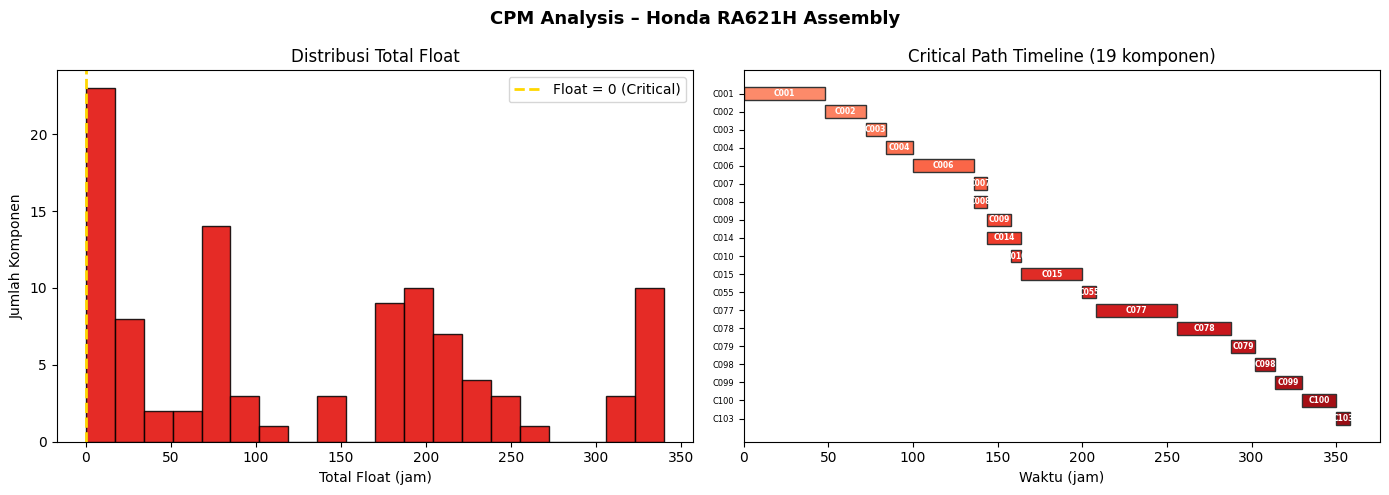

Plot tersimpan: cpm_analysis.png


In [25]:
import numpy as np

df_cpm = df_comp.copy()
df_cpm['ES']    = df_cpm['Component ID'].map(ES)
df_cpm['EF']    = df_cpm['Component ID'].map(EF)
df_cpm['LS']    = df_cpm['Component ID'].map(LS)
df_cpm['LF']    = df_cpm['Component ID'].map(LF)
df_cpm['Float'] = df_cpm['Component ID'].map(float_val)
df_cpm['on_cp'] = df_cpm['Float'] == 0

# ── Plot 1: Float histogram ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CPM Analysis – Honda RA621H Assembly', fontsize=13, fontweight='bold')

axes[0].hist(df_cpm['Float'], bins=20, color='#E10600', edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='#FFD700', linewidth=2, linestyle='--', label='Float = 0 (Critical)')
axes[0].set_title('Distribusi Total Float')
axes[0].set_xlabel('Total Float (jam)')
axes[0].set_ylabel('Jumlah Komponen')
axes[0].legend()

# ── Plot 2: Gantt-style timeline critical path ────────────────────────
cp_df = df_cpm[df_cpm['on_cp']].sort_values('ES').reset_index(drop=True)
colors_cp = plt.cm.Reds(np.linspace(0.4, 0.9, len(cp_df)))

axes[1].set_title(f'Critical Path Timeline ({len(cp_df)} komponen)')
for idx, row in cp_df.iterrows():
    axes[1].barh(idx, row['Duration (hrs)'], left=row['ES'],
                 color=colors_cp[idx], edgecolor='#333333', height=0.7)
    axes[1].text(row['ES'] + row['Duration (hrs)'] / 2, idx,
                 row['Component ID'], ha='center', va='center',
                 fontsize=5.5, fontweight='bold', color='white')

axes[1].set_yticks(range(len(cp_df)))
axes[1].set_yticklabels([f"{r['Component ID']}" for _, r in cp_df.iterrows()], fontsize=6)
axes[1].set_xlabel('Waktu (jam)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('cpm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: cpm_analysis.png')

In [26]:
cp_from_cpm     = set(critical_path_nodes)
cp_from_dataset = set(df_comp[df_comp['is_critical']]['Component ID'].tolist())

match      = cp_from_cpm == cp_from_dataset
only_cpm   = cp_from_cpm   - cp_from_dataset
only_data  = cp_from_dataset - cp_from_cpm

print(f'Critical path nodes dari CPM algorithm : {len(cp_from_cpm)}')
print(f'Critical path nodes dari dataset label : {len(cp_from_dataset)}')
print(f'Exact match                            : {match}')
if only_cpm:
    print(f'Hanya di CPM (tidak di dataset)        : {sorted(only_cpm)}')
if only_data:
    print(f'Hanya di dataset (tidak di CPM)        : {sorted(only_data)}')

Critical path nodes dari CPM algorithm : 19
Critical path nodes dari dataset label : 52
Exact match                            : False
Hanya di CPM (tidak di dataset)        : ['C007', 'C008', 'C010']
Hanya di dataset (tidak di CPM)        : ['C012', 'C016', 'C017', 'C018', 'C019', 'C020', 'C024', 'C025', 'C026', 'C027', 'C029', 'C030', 'C031', 'C032', 'C034', 'C035', 'C036', 'C038', 'C040', 'C047', 'C049', 'C052', 'C053', 'C068', 'C070', 'C072', 'C073', 'C076', 'C081', 'C082', 'C087', 'C091', 'C093', 'C097', 'C101', 'C102']


In [28]:
print('=' * 65)
print('Summary – Honda RA621H | DAG + Kahn\'s + CPM')
print('=' * 65)
print(f'  Total komponen (nodes)       : {G.number_of_nodes()}')
print(f'  Total dependency (edges)     : {G.number_of_edges()}')
print(f'  Root nodes                   : {len(root_nodes)}')
print(f'  Leaf nodes                   : {len(leaf_nodes)}')
print(f'  Is valid DAG (acyclic)       : {nx.is_directed_acyclic_graph(G)}')
print(f'  Kahn\'s sort valid            : {len(topo_order) == G.number_of_nodes()}')
print()
print(f'  Project Duration (CPM)       : {project_duration} jam')
print(f'  Critical path nodes          : {len(critical_path_nodes)}')
print(f'  Non-critical (ada slack)     : {G.number_of_nodes() - len(critical_path_nodes)}')
print(f'  Max float (paling fleksibel) : {int(max(float_val.values()))} jam')
print()
print(f'  Critical path mulai dari     : {critical_path_nodes[0]} – {G.nodes[critical_path_nodes[0]]["label"]}')
print(f'  Critical path berakhir di    : {critical_path_nodes[-1]} – {G.nodes[critical_path_nodes[-1]]["label"]}')

Summary – Honda RA621H | DAG + Kahn's + CPM
  Total komponen (nodes)       : 103
  Total dependency (edges)     : 216
  Root nodes                   : 10
  Leaf nodes                   : 8
  Is valid DAG (acyclic)       : True
  Kahn's sort valid            : True

  Project Duration (CPM)       : 358 jam
  Critical path nodes          : 19
  Non-critical (ada slack)     : 84
  Max float (paling fleksibel) : 340 jam

  Critical path mulai dari     : C001 – V6 Cylinder Block (1.6L 90° Bank)
  Critical path berakhir di    : C103 – Full Car Systems Check & Sign-Off
